# НИС «Основы анализа данных в Python»

*Алла Тамбовцева*

## Практикум 7. Датафреймы `pandas`: описательные статистики и заполнение пропущенных значений

В файле `hse_sample.csv` (скачать [здесь](https://github.com/allatambov/PyDat25/blob/main/hse_sample.csv)) сохранены посты сообщества [Цитатник ВШЭ](https://vk.com/hseteachers) ВКонтакте с числом лайков более 200:

* `id`: id поста;
* `text`: текст поста;
* `nreposts`: число репостов;
* `nlikes`: число лайков;
* `nviews`: число просмотров.
* `tag`: первый тэг после текста.

В файле `hse_dates.csv` (скачать [здесь](https://github.com/allatambov/PyDat25/blob/main/hse_dates.csv)) собрана информация по времени публикации постов в разных форматах:

* `id`: id поста;
* `datetime`: дата публикации поста в формате ГГГГ-ММ-ДД ЧЧ:ММ:СС.

Скачайте данные и загрузите их в датафреймы `df1` и `df2` соответственно.

In [1]:
import pandas as pd

In [2]:
df1 = pd.read_csv("hse_sample.csv")
df1.head()

,id,text,nreposts,nlikes,nviews,tag
0,40321,"Студенты Вышки неубиваемые, их практически нев...",40,251,8322.0,Быков_ВШЭ
1,40273,с: А во время экзамена с прокторингом можно ду...,186,596,12407.0,Преподаватель_ВШЭ
2,40261,П: У кого родители социологи? *ноль рук* С: Со...,60,240,8453.0,Подвойский_ВШЭ
3,40198,"«Студенты мгимо - сынки, а мы - self-made.",75,264,9496.0,Ледяев_ВШЭ
4,40188,Проект выполняется в командах (при тяжелой соц...,30,206,7739.0,Казун_ВШЭ


In [3]:
df2 = pd.read_csv("hse_dates.csv")
df2.head()

,id,datetime
0,40491,2025-04-18 13:22:37
1,40489,2025-04-17 14:38:47
2,40488,2025-04-12 12:24:34
3,40485,2025-04-05 12:11:36
4,40482,2025-03-31 11:34:55


## Часть 1. Объединение датафреймов и формат дата-время

### Задача 1.1

Запросите размерность датафреймов `df1` и `df2`.

In [4]:
print(df1.shape)
print(df2.shape)

(1727, 6)
(10060, 2)


### Задача 1.2

Объедините датафреймы `df1` и `df2` по общему столбцу и сохраните результаты в датафрейм `data`. Выведите размерность полученного датафрейма.

In [5]:
data = df1.merge(df2, on = "id")
print(data.shape)

(1727, 7)


### Задача 1.3

Добавьте в `data` столбец `year` с годом публикации поста и столбец `month` с месяцем публикации поста.

In [6]:
# меняем тип столбца datetime с object на datetime

data["datetime"] = data["datetime"].astype("datetime64[ns]")
print(data.dtypes)

id                   int64
text                object
nreposts             int64
nlikes               int64
nviews             float64
tag                 object
datetime    datetime64[ns]
dtype: object


In [7]:
# извлекаем год и месяц

data["year"] = data["datetime"].dt.year
data["month"] = data["datetime"].dt.month
data.head()

,id,text,nreposts,nlikes,nviews,tag,datetime,year,month
0,40321,"Студенты Вышки неубиваемые, их практически нев...",40,251,8322.0,Быков_ВШЭ,2024-10-22 13:51:24,2024,10
1,40273,с: А во время экзамена с прокторингом можно ду...,186,596,12407.0,Преподаватель_ВШЭ,2024-09-28 14:17:25,2024,9
2,40261,П: У кого родители социологи? *ноль рук* С: Со...,60,240,8453.0,Подвойский_ВШЭ,2024-09-24 14:52:50,2024,9
3,40198,"«Студенты мгимо - сынки, а мы - self-made.",75,264,9496.0,Ледяев_ВШЭ,2024-09-08 11:55:00,2024,9
4,40188,Проект выполняется в командах (при тяжелой соц...,30,206,7739.0,Казун_ВШЭ,2024-09-03 11:16:49,2024,9


## Часть 2: поиск и заполнение пропусков

### Задача 2.1

Вычислите количество пропущенных значений в столбце с числом просмотров.

In [8]:
data["nviews"].isna().sum()

473

### Задача 2.2

Выведите описательные статистики для числа просмотров. Постройте ящик с усами для изучаемого показателя. Какую меру центральной тенденции необходимо выбрать для описания данных?

**Подсказка:** ящик с усами – метод `.plot.box()`.

In [9]:
data["nviews"].describe()

count     1254.000000
mean     10632.700957
std       5005.661231
min       4284.000000
25%       7215.250000
50%       9539.000000
75%      12700.000000
max      48847.000000
Name: nviews, dtype: float64

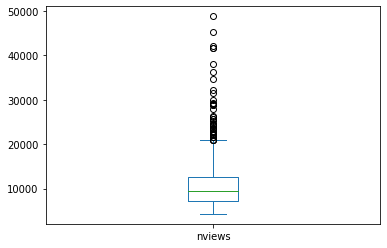

In [10]:
data["nviews"].plot.box();

> Ответ: медиану, так как признак количественный + есть нехарактерно большие значения (среднее не очень информативно здесь, «завышено»).

In [11]:
# заодно выясним, что это за пост с максимальным числом просмотров

data[data["nviews"] == data["nviews"].max()]

,id,text,nreposts,nlikes,nviews,tag,datetime,year,month
281,37028,"Больше 12-15 страниц никто не читает, и то это...",599,1894,48847.0,Круглова_ВШЭ,2022-07-08 11:45:00,2022,7


In [12]:
# посмотрим на текст отдельно – извлечем содержимое ячейки

data[data["nviews"] == data["nviews"].max()].loc[281, "text"]

'Больше 12-15 страниц никто не читает, и то это много. Я подозреваю, года через два вам придётся укладывать вашу диссертацию в тикток.'

### Задача 2.3

Заполните пропущенные значения в столбце с числом просмотров, используя значение статистики, выбранной в предыдущей задаче. Не сохраняйте изменения в датафрейме, сохраните столбец без пропусков в отдельную переменную `nviews01`. Выведите описательные статистики для столбца после заполнения пропусков.

Заполните пропущенные значения в столбце с числом просмотров, используя значение другой подходящей меры центральной тенденции. Не сохраняйте изменения в датафрейме, сохраните столбец без пропусков в отдельную переменную `nviews02`. Выведите описательные статистики для столбца после заполнения пропусков.

**Подсказка:** метод `.fillna()`.

In [13]:
# считаем медиану и вместо пропусков NaN подставляем ее значение

med = data["nviews"].median()
nviews01 = data["nviews"].fillna(med)
nviews01.describe()

count     1727.000000
mean     10333.152287
std       4292.789954
min       4284.000000
25%       7820.500000
50%       9539.000000
75%      11359.500000
max      48847.000000
Name: nviews, dtype: float64

> **Комментарий.** Если сравним описательные статистики до и после заполнения пропусков, заметим, что после заполнения пропусков медианой, медиана показателя не изменилась, а среднее изменилось, но незначительно. При этом характер распределения сохранился – по-прежнему большой разрыв между верхним квартилем и максимумом, есть нехарактерно большие значения.

In [14]:
# считаем среднее и вместо пропусков NaN подставляем его значение

mean = data["nviews"].mean()
nviews02 = data["nviews"].fillna(mean)
nviews02.describe()

count     1727.000000
mean     10632.700957
std       4264.976026
min       4284.000000
25%       7820.500000
50%      10632.700957
75%      11359.500000
max      48847.000000
Name: nviews, dtype: float64

> **Комментарий.** Если сравним описательные статистики до и после заполнения пропусков, заметим, что после заполнения пропусков средним, среднее показателя не изменилось, а медиана изменилась, но незначительно. При этом характер распределения сохранился – по-прежнему большой разрыв между верхним квартилем и максимумом, есть нехарактерно большие значения. В данном случае медиана и среднее после заполнения пропусков совпали, однако это необязательно всегда будет так. Зато получилась наглядная иллюстрация того, что совпадение среднего и медианы не всегда гарантирует симметричность распределения и отсутствие нехарактерных значений.

## Часть 3: группировка и заполнение пропущенных значений

### Задача 3.1

* Сгруппируйте строки по году публикации поста и выведите описательные статистики для числа просмотров. 
* Сгруппируйте строки по месяцу публикации поста и выведите описательные статистики для числа просмотров. 

Также выведите отдельно среднее число просмотров для каждой группы.

**Подсказка:** метод `.groupby()`.

In [15]:
# группируем строки по году year
# выбираем из каждой группы столбец nviews
# описываем его через .describe()

data.groupby("year")["nviews"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2013,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017,153.0,7643.954248,2176.953298,4768.0,6117.00,7062.0,8590.00,15428.0
2018,185.0,7249.740541,1972.201145,4284.0,5953.00,6831.0,8012.00,16414.0
2019,266.0,10179.101504,4462.733006,4975.0,7223.75,8845.0,11690.75,34652.0
2020,139.0,9195.539568,3497.973644,4657.0,6775.50,7940.0,10687.50,20055.0
2021,134.0,10757.723881,3985.758658,5767.0,7927.50,9401.5,12525.25,29098.0


> **Комментарий.** До 2017 года число просмотров не фиксировалось, поэтому в столбце `nviews` за эти годы все ячейки пустые – отсюда число заполненных значений в `count`, равное 0. И невозможность рассчитать описательные статистики.

In [16]:
# группируем строки по месяцу month
# выбираем из каждой группы столбец nviews
# описываем его через .describe()

data.groupby("month")["nviews"].describe()

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
1,121.0,11530.826446,4431.414691,5346.0,8434.00,10509.0,12996.00,29335.0
2,124.0,9809.016129,4612.161770,4975.0,6715.00,8608.0,10967.75,31540.0
3,103.0,10013.932039,3113.580139,4657.0,7816.00,9552.0,11716.00,21047.0
4,81.0,10652.481481,4271.040304,5342.0,7675.00,9902.0,12061.00,28854.0
5,72.0,11305.555556,3357.412237,6628.0,9372.00,10871.0,12287.50,25771.0
6,61.0,12701.114754,3586.935968,7428.0,10341.00,12230.0,14269.00,24569.0
7,48.0,15464.958333,7223.068623,9053.0,11221.75,14001.5,16597.25,48847.0
8,29.0,15534.206897,4551.126637,7704.0,13343.00,14625.0,16707.00,32284.0
9,143.0,10337.181818,5935.395023,5129.0,6446.50,8072.0,12332.50,45310.0


In [17]:
data.groupby("month")["nviews"].mean()

month
1     11530.826446
2      9809.016129
3     10013.932039
4     10652.481481
5     11305.555556
6     12701.114754
7     15464.958333
8     15534.206897
9     10337.181818
10     9152.144654
11     9588.541353
12    10207.283333
Name: nviews, dtype: float64

### Задача 3.2

Изучите содержимое результата `.groupby()` и, используя его структуру, сохраните в отдельные CSV-файлы строки, соответствующие постам, опубликованным в каждый месяц (разные годы, файл `01.csv` с постами за январь, файл `02.csv` с постами за февраль, и так далее).

**Подсказка:** метод `.to_csv()`.

In [18]:
data.groupby("month")

In [19]:
# раскомментируйте строку ниже, 
# получится большой список с кортежами
# list(data.groupby("month"))

# а вот и первый элемент такого списка

list(data.groupby("month"))[0]

(1,          id                                               text  nreposts  \
 39    39743  Михаил, у меня есть ощущение, что Вы здесь всё...        48   
 40    39736  Нельзя дать всем всё, потому что всех много, а...        59   
 41    39730  Как я люблю работать с теми, кто ничего не зна...        41   
 42    39706  - Я немного не поняла смысл этой статьи. - Это...        35   
 43    39699  Я вот вижу, что люди такие запуганные становят...        45   
 ...     ...                                                ...       ...   
 1718    588  'У студентки упал айпад на лекции'. Мельник(М)...         3   
 1719    582  "Больные пошли нынче студенты. Вы чего на перв...         7   
 1720    429  Вы вообще в какой стране родились? Откуда у Ва...        12   
 1721    333  ... Его работа называлась "Органон". Запомните...         6   
 1722    214  Функция, конечно, поломается... Ты ее и так, и...         6   
 
       nlikes   nviews            tag            datetime  year  month 

> **Комментарий.** Результат `.groupby()` – объект специального типа `DataFrameGroupBy`, содержимое которого от нас скрыто и временно хранится в какой-то ячейке памяти. Если преобразовать этот объект в более понятный список через функцию `list()`, получим список из 12 пар, на первом месте в каждой паре – номер месяца (группировка по `month`), на втором – датафрейм со строками, соответствующими этому месяцу.

In [25]:
# проходим в цикле по набору пар 
# (название группы name, датафрейм для группы df)
# выгружаем df с названием name + расширение .csv

for name, df in data.groupby("month"):
    df.to_csv(str(name) + ".csv")

Теперь в рабочей папке, которая отображается в *Home* в Jupyter, должны добавиться двенадцать CSV-файлов (`1.csv`, `2.csv` и так далее до `12.csv`), в каждом – строки из `data`, соответствующие каждому месяцу.

Если нужно, можем из результата группировки забрать датафрейм для конкретной группы – вызвать метод `.get_group()` и указать название группы:

In [26]:
# строки data за декабрь, month = 12

data.groupby("month").get_group(12)

,id,text,nreposts,nlikes,nviews,tag,datetime,year,month
51,39631,"Учитесь не радоваться хорошим результатам, тог...",29,230,10730.0,Володин_ВШЭ,2023-12-31 11:50:00,2023,12
52,39626,Образование - это всегда насилие.,54,302,12556.0,Цифровая_картография_и_геоинформационныесистемы,2023-12-28 11:50:00,2023,12
53,39600,Лекция - это акт любви. А записывать акты любв...,203,520,12666.0,Каспэ_ВШЭ,2023-12-22 11:55:00,2023,12
54,39596,(обсуждает различия в звучании слов) Love is a...,24,219,9789.0,Даценко_ВШЭ,2023-12-21 11:55:00,2023,12
55,39595,"""На лекции уже прилично так людей, целых 15"".",29,347,11780.0,Скриба_ВШЭ,2023-12-20 11:55:00,2023,12
...,...,...,...,...,...,...,...,...,...
1467,5167,"Никакого насилия над функциями на контрольной,...",4,272,NaN,Самовол_hse,2014-12-04 15:37:49,2014,12
1723,175,ТГП. Назмутдинов Булат Венерович (Б. В.) и Сер...,7,212,NaN,Булат_hse,2013-12-29 19:48:23,2013,12
1724,170,На алгебре решаем пример. Самовол :ну что полу...,11,393,NaN,Самовол_hse,2013-12-29 16:31:28,2013,12
1725,159,"-Катя, куда вы? -Выйти. Я решила вас не беспок...",2,213,NaN,Павлов_hse,2013-12-29 13:43:53,2013,12


**Дополнительно 1.** Как получить перечень файлов в рабочей папке? Импортировать модуль `os` для работы с операционной системой и через функцию `listdir()` запросить список названий файлов рабочей папки:

In [27]:
import os
os.listdir()

['6.csv',
 '7.csv',
 '5.csv',
 'hse_sample.csv',
 '4.csv',
 'pydat-practice06.ipynb',
 '.DS_Store',
 '1.csv',
 '3.csv',
 '2.csv',
 'Untitled.ipynb',
 'pydat-practice07-solved.ipynb',
 'pydat-practice07.ipynb',
 'hse.xlsx',
 '10.csv',
 '11.csv',
 '12.csv',
 '02-Описание данных.key',
 '.ipynb_checkpoints',
 '9.csv',
 '8.csv',
 'hse_dates.csv']

**Дополнительно 2.** Формально, по условию от нас ожидаются названия файлов вида `01.csv`, то есть с дописанными нулями, если номер месяц не двузначный. Такие названия – более корректные с точки зрения сортировки файлов по названиям. Система/Python сравнивает текстовые строки посимвольно, поэтому сортировка сейчас даст следующий результат:

In [28]:
# 1.csv, 10.csv, 11.csv, 12.csv 
# сначала все названия с 1 на первом месте,
# хронология нарушается

sorted(os.listdir())

['.DS_Store',
 '.ipynb_checkpoints',
 '02-Описание данных.key',
 '1.csv',
 '10.csv',
 '11.csv',
 '12.csv',
 '2.csv',
 '3.csv',
 '4.csv',
 '5.csv',
 '6.csv',
 '7.csv',
 '8.csv',
 '9.csv',
 'Untitled.ipynb',
 'hse.xlsx',
 'hse_dates.csv',
 'hse_sample.csv',
 'pydat-practice06.ipynb',
 'pydat-practice07-solved.ipynb',
 'pydat-practice07.ipynb']

Удалим файлы, которые создали перед этим:

In [29]:
for i in range(1, 13):
    os.remove(str(i) + ".csv")

In [30]:
# удалились!

sorted(os.listdir())

['.DS_Store',
 '.ipynb_checkpoints',
 '02-Описание данных.key',
 'Untitled.ipynb',
 'hse.xlsx',
 'hse_dates.csv',
 'hse_sample.csv',
 'pydat-practice06.ipynb',
 'pydat-practice07-solved.ipynb',
 'pydat-practice07.ipynb']

Чтобы дописать недостающие нули, можно воспользоваться методом `.zfill()` на строках (от *zero filling*):

In [31]:
# zfill(2) – если необходимо, добавь 0 в начале строки,
# чтобы в ней стало 2 символа, если уже 2 символа, 
# не делай ничего

for name, df in data.groupby("month"):
    df.to_csv(str(name).zfill(2) + ".csv")

In [32]:
# вот теперь хорошо

sorted(os.listdir())

['.DS_Store',
 '.ipynb_checkpoints',
 '01.csv',
 '02-Описание данных.key',
 '02.csv',
 '03.csv',
 '04.csv',
 '05.csv',
 '06.csv',
 '07.csv',
 '08.csv',
 '09.csv',
 '10.csv',
 '11.csv',
 '12.csv',
 'Untitled.ipynb',
 'hse.xlsx',
 'hse_dates.csv',
 'hse_sample.csv',
 'pydat-practice06.ipynb',
 'pydat-practice07-solved.ipynb',
 'pydat-practice07.ipynb']

### Задача 3.3

Заполните пропуски в `nviews` средними значениями по каждому месяцу (средними по году не получится – число просмотров до 2017 года не фиксировалось). 

In [33]:
# код уже написан

data["nviews"] = data.groupby('month')['nviews'].transform(lambda x: x.fillna(x.mean()))

**Комментарий.** Метод `.transform()` ведёт себя аналогично `.apply()`, он умеет применять функцию к столбцам датафрейма, с учётом группировки в том числе. Здесь мы делаем следующее:

* Группируем строки в `data` на основе столбца `month`. Получаем набор из 12 датафреймов, один на каждый месяц. 

* В каждом из двенадцати датафреймов выбираем столбец `nviews` и применяем к нему функцию, которую напишем в `.transform()`. Эта функция одновременно применится 12 раз, к столбцу `nviews` в датафрейме за каждый месяц.

* Раз пишем `.transform()` для столбца `nviews`, далее в lambda-функции `x` – это столбец `nviews` в датафрейме за один из 12 месяцев. Мы вычисляем среднее по этому столбцу через `x.mean()` и заполняем им пропуски через `.fillna()`.

Получается, мы отдельно для каждого месяца вычисляем среднее число просмотров (`x.mean()`), отдельно в рамках каждого месяца заполняем пропуски полученными средними (свое значение для каждого месяца, оно подставляется в `x.fillna()`), а затем просто сохраняем изменения в столбце, перезаписывая его через `=`.

Сгруппируйте строки по году и проверьте, что теперь пропусков в данных нет.

In [34]:
# в count везде не 0

data.groupby("year").describe()

id                                                                   \
      count          mean          std      min       25%      50%       75%   
year                                                                           
2013    4.0    154.500000    27.814864    114.0    147.75    164.5    171.25   
2014  279.0   3260.487455  1455.000504    214.0   2016.00   3417.0   4506.00   
2015   92.0   5963.760870   285.811602   5502.0   5718.50   6005.0   6183.75   
2016   98.0   9735.214286  1651.217060   6642.0   8104.25  10118.5  11236.25   
2017  153.0  14204.620915  1242.433150  11987.0  13142.00  14113.0  15287.00   
2018  185.0  20020.751351  1965.099971  16449.0  18784.00  19887.0  21936.00   
2019  266.0  25406.657895  1682.201482  22800.0  23947.25  25255.5  26694.00   
2020  139.0  30655.215827  1229.204266  28538.0  29824.00  30601.0  31729.50   
2021  134.0  34678.970149  1024.069759  32748.0  33790.00  34859.5  35583.00   
2022  196.0  37034.040816   569.891072  35930.0  36564.25  37060.5  37541.25   
2023  130.0  38807.146154   467.431479  38047.0  38415.25  38734.5  39153.50   
2024   51.0  39912.019608   176.024145  39650.0  39758.50  39923.0  40022.50   

              nreposts             ...        nviews                month  \
          max    count       mean  ...           75%           max  count   
year                               ...                                      
2013    175.0      4.0   8.000000  ...  10207.283333  10207.283333    4.0   
2014   5461.0    279.0   9.279570  ...  10652.481481  12701.114754  279.0   
2015   6432.0     92.0   8.282609  ...  11530.826446  12701.114754   92.0   
2016  11964.0     98.0   5.959184  ...  10337.181818  12701.114754   98.0   
2017  16402.0    153.0   4.163399  ...   8590.000000  15428.000000  153.0   
2018  22791.0    185.0   5.059459  ...   8012.000000  16414.000000  185.0   
2019  28530.0    266.0   4.691729  ...  11690.750000  34652.000000  266.0   
2020  32739.0    139.0   7.935252  ...  10687.500000  20055.000000  139.0   
2021  35928.0    134.0  76.492537  ...  12525.250000  29098.000000  134.0   
2022  38044.0    196.0  89.173469  ...  17089.750000  48847.000000  196.0   
2023  39631.0    130.0  74.561538  ...  13379.500000  31540.000000  130.0   
2024  40321.0     51.0  54.980392  ...  12243.000000  22391.000000   51.0   

                                                          
           mean       std   min    25%   50%   75%   max  
year                                                      
2013  12.000000  0.000000  12.0  12.00  12.0  12.0  12.0  
2014   6.448029  3.891975   1.0   3.00   6.0  10.0  12.0  
2015   2.608696  1.459765   1.0   1.00   2.0   4.0   6.0  
2016   9.265306  3.101549   1.0   9.00  10.0  11.0  12.0  
2017   8.699346  3.252701   1.0   9.00  10.0  11.0  12.0  
2018   8.805405  3.701494   1.0   9.00  10.0  12.0  12.0  
2019   5.650376  3.713557   1.0   2.00   5.0   9.0  12.0  
2020   7.129496  3.952315   1.0   3.50   9.0  11.0  12.0  
2021   7.686567  4.082639   1.0   3.25   9.0  11.0  12.0  
2022   6.882653  3.459881   1.0   4.00   7.0  10.0  12.0  
2023   6.069231  3.628459   1.0   3.00   5.0   9.0  12.0  
2024   3.411765  2.393127   1.0   2.00   3.0   4.5  10.0  

[12 rows x 40 columns]